# **Multi-Armed Bandit Problem**
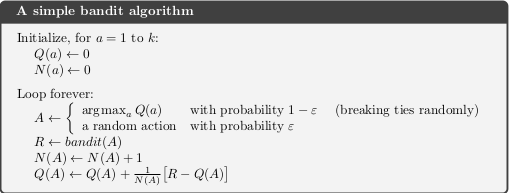

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

**Variable Descriptions**

- `k` → Number of arms  
- `true_action_values` → True action values (true mean rewards)  
- `reward_variance` → Reward variance for each arm  
- `Q_est` → Estimated action-value function  
- `N` → Number of times each arm is selected  
- `epsilon` → Exploration probability  
- `A` → Selected action  
- `R` → Observed reward  
- `cumulative_reward` → Cumulative reward


mean_value = [1 5 7 6 3 8 9 2 0 4]
Q_est (Estimated action-value function) = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
N (Number of times each arm is selected) = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
epsilon = 0.1
----------------------------------------
----------------------------------------


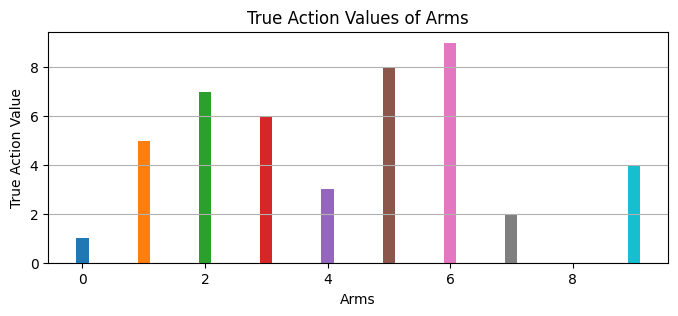

In [ ]:
# np.random.seed(4)

k = 10 # Number of arms (actions)
Episode = 1000
n_steps = 2000

true_action_values = np.random.choice(10, size=k, replace=False) # Optimal action values

Q_est = np.zeros(k) # Estimated action-value function
N = np.zeros(k) # Number of times each arm is selected
epsilon = 0.1
cumulative_reward = np.zeros((Episode, n_steps))
optimal_actions = np.zeros((Episode, n_steps))
selected_actions = np.zeros((Episode, n_steps))
OAP = np.zeros((Episode, n_steps)) # Optimal Action Percent


print('mean_value =', true_action_values)
print('Q_est (Estimated action-value function) =', Q_est)
print('N (Number of times each arm is selected) =', N)
print('epsilon =', epsilon)

print('----------------------------------------')
print('----------------------------------------')


plt.figure(figsize=(8,3))

for i in range(true_action_values.size):
  plt.bar(i, true_action_values[i], width=0.2)

plt.ylabel('True Action Value')
plt.xlabel('Arms')
plt.title('True Action Values of Arms')
plt.grid(axis='y')
plt.show()

# **Epsilon-Greedy Algorithm for non-stationary (dynamic) systems**

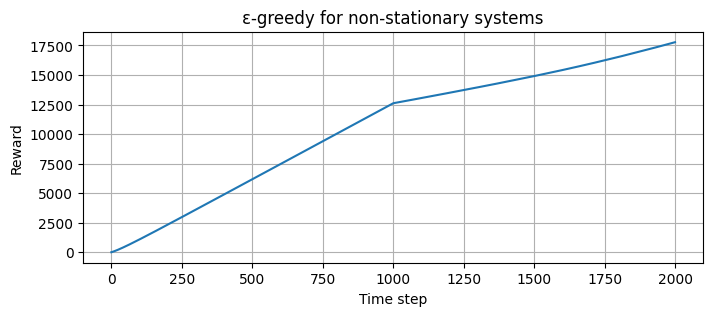

----------------------------------------


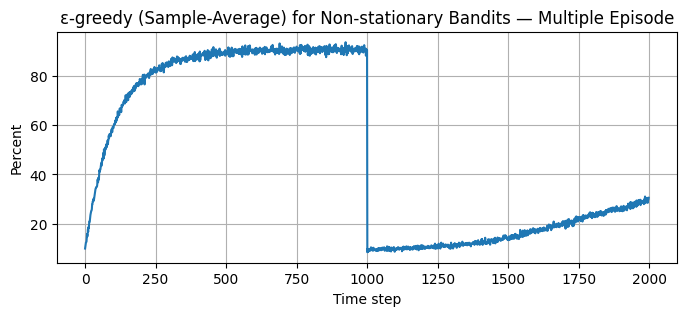

Optimal Action Percent =  49.185 %


In [ ]:
for E in range(Episode):

  for i in range(n_steps):

    if(np.random.rand() > epsilon): # Exploitation
      # print('Exploitation')
      A = np.argmax(Q_est)
      N[A] = N[A] + 1
      R = true_action_values[A] + np.random.randn()
      Q_est[A] = Q_est[A] + (1/N[A]) * (R - Q_est[A]) # Sample average

    else: # Exploration
      # print('Exploration')
      A = np.random.randint(0, k)
      N[A] = N[A] + 1
      R = true_action_values[A] + np.random.randn()
      Q_est[A] = Q_est[A] + (1/N[A]) * (R - Q_est[A]) # Sample average


    optimal_actions[E][i] = np.argmax(true_action_values)
    selected_actions[E][i] = A
    OAP[E][i] = (optimal_actions[E][i] == selected_actions[E][i]) * 100



    if i==0:
      cumulative_reward[E][i] = R
    else:
      cumulative_reward[E][i] = cumulative_reward[E][i-1]+R

    if i==1000: # Dynamic system changes at i = 1000
      true_action_values = np.random.choice(10, size=k, replace=False)

  true_action_values = np.random.choice(15, size=k, replace=False) # Optimal action values
  Q_est = np.zeros(k)
  N = np.zeros(k)

plt.figure(figsize=(8,3))
plt.plot(np.mean(cumulative_reward, axis=0))
plt.title('ε-greedy for non-stationary systems')
plt.ylabel('Reward')
plt.xlabel('Time step')
plt.grid()
plt.show()


print('----------------------------------------')

plt.figure(figsize=(8,3))
plt.plot(np.mean(OAP, axis=0))
plt.xlabel('Time step')
plt.ylabel('Percent')
plt.title('ε-greedy (Sample-Average) for Non-stationary Bandits — Multiple Episode')
plt.grid()
plt.show()
print('Optimal Action Percent = ', ((np.sum(optimal_actions == selected_actions)*100))/(n_steps*Episode), '%')